<a href="https://colab.research.google.com/github/seongwoojang1123/Effusion-OSA-TMD/blob/main/3_Logistic_Regression_Training_Effusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from scipy import stats

file_path = '/content/drive/MyDrive/Effusion OSA TMD/20250831_Effusion_TMD_Pain_Data.xlsx'

df = pd.read_excel(file_path, sheet_name='20250830_20250829_20250226_2024')

Effusion(0,1) ROC with Color + 95% CI

AUROC: 0.816
AUROC 95% CI: [0.652, 0.945]
P-value (AUC > 0.5): 1.16e-05
Incidence Rate (Effusion=1 비율): 0.697


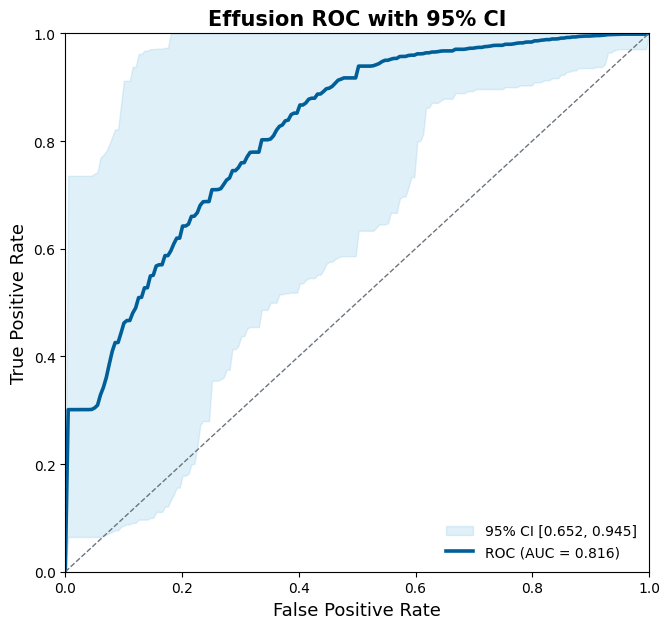


Summary:
 AUROC  AUROC_95CI_Lower  AUROC_95CI_Upper  P_value_(AUC>0.5)  IR_(Effusion=1_ratio)
 0.816             0.652             0.945           0.000012                  0.697


In [2]:
#    - outcome: Effusion (0/1, B열)
#    - features: E~R열 중 Effusion_123 제외 (사용자 적용대로 4:17)
# ------------------------------------------------------------
y = df['Effusion']
X = df.iloc[:, 4:17].fillna(0)  # Age ~ Bruxism

# ------------------------------------------------------------
# 1) Train/Test split + 스케일링
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ------------------------------------------------------------
# 2) 모델 학습 (Logistic Regression)
# ------------------------------------------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 3) AUROC (점추정)
# ------------------------------------------------------------
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("AUROC:", round(roc_auc, 3))

# ------------------------------------------------------------
# 4) AUROC 95% CI (bootstrap on AUC)
# ------------------------------------------------------------
n_bootstraps = 2000
rng = np.random.RandomState(42)
boot_auc = []

for _ in range(n_bootstraps):
    idx = rng.randint(0, len(y_test), len(y_test))
    y_bs = y_test.iloc[idx]
    p_bs = y_pred_proba[idx]
    # 양쪽 클래스 모두 있어야 AUC 계산 가능
    if len(np.unique(y_bs)) < 2:
        continue
    boot_auc.append(roc_auc_score(y_bs, p_bs))

boot_auc = np.array(boot_auc)
ci_lower = np.percentile(boot_auc, 2.5)
ci_upper = np.percentile(boot_auc, 97.5)
print(f"AUROC 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

# p-value (H0: AUC=0.5)
z_stat = (roc_auc - 0.5) / (np.std(boot_auc, ddof=1) + 1e-12)
p_value = 1 - stats.norm.cdf(z_stat)
print("P-value (AUC > 0.5):", f"{p_value:.4g}")

# Incidence Rate
IR = y.mean()
print("Incidence Rate (Effusion=1 비율):", f"{IR:.3f}")

# ------------------------------------------------------------
# 5) ROC Curve + 95% CI 밴드 (부트스트랩 ROC 기반)
#   - 색상: 평균 ROC = 진청 #005f99, CI 밴드 = 파스텔 블루 #8ecae6
#   - Test ROC(raw), Youden-optimal 은 표기하지 않음 (요청 반영)
# ------------------------------------------------------------
# (a) test ROC 좌표
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# (b) bootstrap ROC로 CI band 계산
fpr_grid = np.linspace(0, 1, 200)
tprs = []

for _ in range(n_bootstraps):
    idx = rng.randint(0, len(y_test), len(y_test))
    y_bs = y_test.iloc[idx]
    p_bs = y_pred_proba[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_bs, tpr_bs, _ = roc_curve(y_bs, p_bs)
    # 보간 (단조 증가 가정)
    tpr_interp = np.interp(fpr_grid, fpr_bs, tpr_bs)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

tprs = np.array(tprs)
tpr_mean  = tprs.mean(axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)
tpr_upper = np.percentile(tprs, 97.5, axis=0)

# (c) 플롯
plt.figure(figsize=(6.8, 6.4))

# 95% CI band
plt.fill_between(
    fpr_grid, tpr_lower, tpr_upper,
    color="#8ecae6", alpha=0.28, label="95% CI [0.652, 0.945]"
)

# 평균 ROC (밴드의 중심)
plt.plot(fpr_grid, tpr_mean, color="#005f99", lw=2.6,
         label=f"ROC (AUC = {roc_auc:.3f})")

# 기준 대각선
plt.plot([0, 1], [0, 1], "--", color="#6c757d", lw=1)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion ROC with 95% CI", fontsize=15, fontweight="bold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) 보고용 요약 테이블 (숫자 결과 정리)
# ------------------------------------------------------------
summary_df = pd.DataFrame([{
    "AUROC": round(roc_auc, 3),
    "AUROC_95CI_Lower": round(ci_lower, 3),
    "AUROC_95CI_Upper": round(ci_upper, 3),
    "P_value_(AUC>0.5)": float(f"{p_value:.4g}"),
    "IR_(Effusion=1_ratio)": round(IR, 3)
}])
print("\nSummary:")
print(summary_df.to_string(index=False))


회귀 계수 (설명 변수 중요도)

In [3]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

            Variable  Coefficient
3                VAS     0.780404
11          Tinnitus     0.656943
4                 DI     0.560050
7   Symptom duration     0.453936
10  Muscle stiffness     0.416605
9            Locking     0.354969
8          TMJ noise     0.338651
1                ADD     0.312122
2                 OA     0.269057
6                CMI     0.138941
0                Age    -0.068985
5                 PI    -0.203152
12           Bruxism    -0.276511


Effusion grade (0/1/2) — OVR ROC with Color + 95% CI

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


AUROC by class: {'Class 0': np.float64(0.7534562211981567), 'Class 1': np.float64(0.6255144032921811), 'Class 2': np.float64(0.5192307692307693)}
Macro-average AUROC: 0.6327337979070357
Micro-average AUROC: 0.6496296296296297


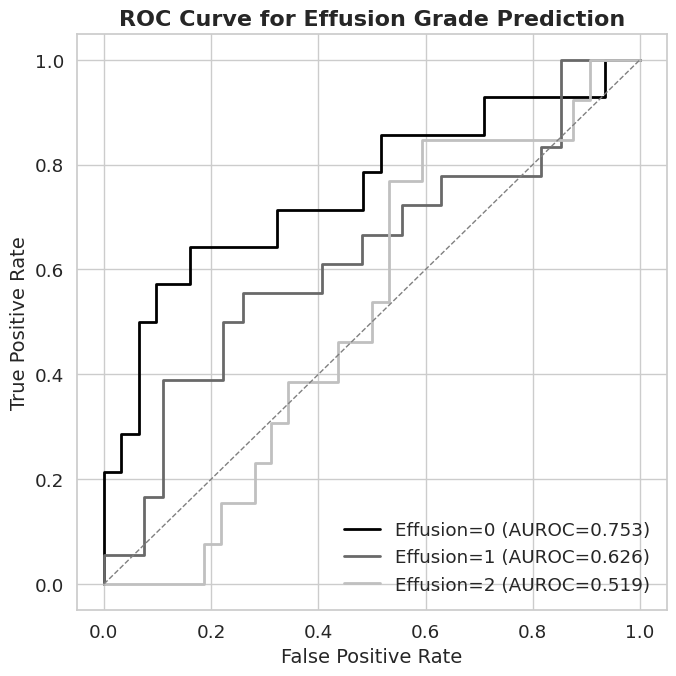

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# outcome (C열: Effusion grade)
y = df['Effusion grade']   # 0,1,2
X = df.iloc[:, 4:17].fillna(0)  # Age~Bruxism

# one-hot encoding for multi-class ROC
y_bin = label_binarize(y, classes=[0,1,2])
n_classes = y_bin.shape[1]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_multi = LogisticRegression(max_iter=1000, multi_class="ovr", random_state=42)
log_reg_multi.fit(X_train_scaled, y_train)

y_score = log_reg_multi.predict_proba(X_test_scaled)

# One-vs-Rest ROC AUC
y_test_bin = label_binarize(y_test, classes=[0,1,2])

auc_dict = {}
for i in range(n_classes):
    auc_dict[f"Class {i}"] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

# Macro & Micro average
macro_auc = roc_auc_score(y_test_bin, y_score, average="macro")
micro_auc = roc_auc_score(y_test_bin, y_score, average="micro")

print("AUROC by class:", auc_dict)
print("Macro-average AUROC:", macro_auc)
print("Micro-average AUROC:", micro_auc)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,7))
sns.set(style="whitegrid", font_scale=1.2)

colors = ["black","dimgray","silver"]
labels = ["Effusion=0","Effusion=1","Effusion=2"]

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"{labels[i]} (AUROC={roc_auc[i]:.3f})")

plt.plot([0,1],[0,1],"--",color="gray",lw=1)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve for Effusion Grade Prediction", fontsize=16, weight="bold")
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()



Per-class AUROC: {'class 0': np.float64(0.753), 'class 1': np.float64(0.626), 'class 2': np.float64(0.519)}
Macro AUROC: 0.633
Micro AUROC: 0.65

95% CI (per-class AUC):
  Class 0: [0.556, 0.905]
  Class 1: [0.447, 0.787]
  Class 2: [0.343, 0.700]

95% CI (Macro AUC): [0.499, 0.753]
95% CI (Micro AUC): [0.523, 0.768]


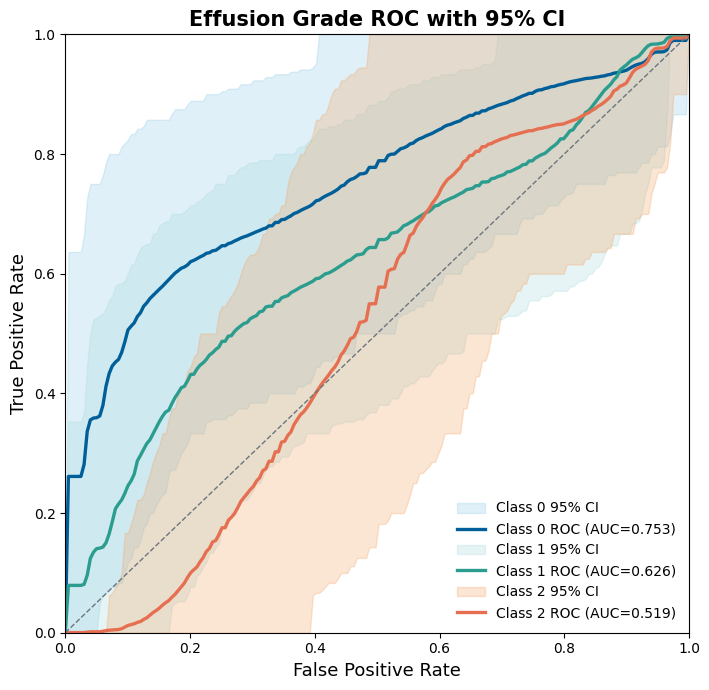


Summary (AUROC with 95% CI):
Class  AUROC  AUROC_95CI_Lower  AUROC_95CI_Upper
    0  0.753             0.556             0.905
    1  0.626             0.447             0.787
    2  0.519             0.343             0.700
Macro  0.633             0.499             0.753
Micro  0.650             0.523             0.768


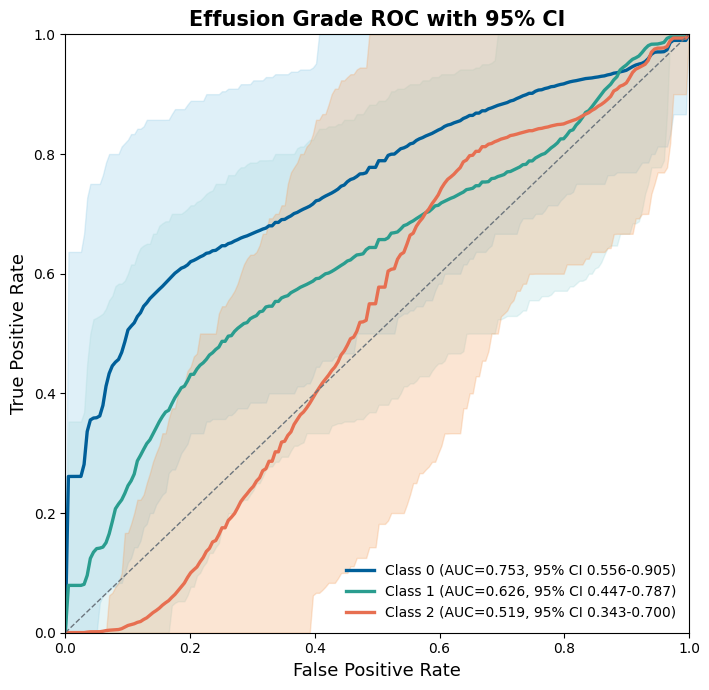

In [7]:

#    - outcome: Effusion grade (0/1/2, C열)
#    - features: E~Q or E~R 중 유효변수 (사용자 기준: 4:17 = Age~Bruxism)
# ------------------------------------------------------------
X = df.iloc[:, 4:17].fillna(0)          # 설명변수
y = df['Effusion grade']                # 0/1/2
classes = [0, 1, 2]

# 이진화 레이블 (OVR ROC 계산용)
y_bin_all = label_binarize(y, classes=classes)  # (N, 3)

# ------------------------------------------------------------
# 1) Train/Test split + 스케일링
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ------------------------------------------------------------
# 2) 모델 학습 (OVR 로지스틱 회귀)
# ------------------------------------------------------------
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
clf.fit(X_train_sc, y_train)

# 예측확률 (n, 3)
y_score = clf.predict_proba(X_test_sc)

# 테스트셋 이진화
y_test_bin = label_binarize(y_test, classes=classes)  # (n, 3)

# ------------------------------------------------------------
# 3) 점추정 AUC (클래스별, macro, micro)
# ------------------------------------------------------------
auc_per_class = {}
for i, c in enumerate(classes):
    auc_per_class[c] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print("Per-class AUROC:", {f"class {c}": round(auc_per_class[c], 3) for c in classes})
print("Macro AUROC:", round(auc_macro, 3))
print("Micro AUROC:", round(auc_micro, 3))

# ------------------------------------------------------------
# 4) 95% CI (bootstrap)
#   - per-class AUC CI
#   - macro/micro AUC CI
#   - per-class ROC CI band (TPR-band vs FPR)
# ------------------------------------------------------------
n_boot = 2000
rng = np.random.RandomState(42)
n = len(y_test)

# 공통 FPR 그리드(보간용)
fpr_grid = np.linspace(0, 1, 200)

# 저장 컨테이너
boot_auc_per_class = {c: [] for c in classes}
boot_auc_macro = []
boot_auc_micro = []
tprs_band = {c: [] for c in classes}  # 각 클래스별 ROC 밴드 계산용

for _ in range(n_boot):
    idx = rng.randint(0, n, n)
    y_bin_bs = y_test_bin[idx]     # (n, 3)
    y_scr_bs = y_score[idx]        # (n, 3)

    # 각 클래스별로, 양·음성 모두 있어야 ROC 가능 → 불가 클래스는 스킵
    valid_for_macro = True
    per_class_auc_this_boot = []

    for i, c in enumerate(classes):
        y_true_i = y_bin_bs[:, i]
        y_sc_i   = y_scr_bs[:, i]

        if len(np.unique(y_true_i)) < 2:
            valid_for_macro = False
            continue

        # AUC
        auc_i = roc_auc_score(y_true_i, y_sc_i)
        boot_auc_per_class[c].append(auc_i)
        per_class_auc_this_boot.append(auc_i)

        # ROC 밴드용 보간 TPR
        fpr_i, tpr_i, _ = roc_curve(y_true_i, y_sc_i)
        tpr_interp = np.interp(fpr_grid, fpr_i, tpr_i)
        tpr_interp[0] = 0.0
        tprs_band[c].append(tpr_interp)

    # macro/micro AUC (해당 부트에서 모든 클래스가 유효한 경우에만)
    if valid_for_macro:
        boot_auc_macro.append(roc_auc_score(y_bin_bs, y_scr_bs, average="macro"))
        boot_auc_micro.append(roc_auc_score(y_bin_bs, y_scr_bs, average="micro"))

# CI 계산 함수
def ci_low_high(arr, lo=2.5, hi=97.5):
    arr = np.asarray(arr, dtype=float)
    return np.percentile(arr, lo), np.percentile(arr, hi)

# per-class AUC CI
ci_per_class = {}
for c in classes:
    if len(boot_auc_per_class[c]) > 0:
        lo, hi = ci_low_high(boot_auc_per_class[c])
        ci_per_class[c] = (lo, hi)
    else:
        ci_per_class[c] = (np.nan, np.nan)  # 표본 부족 등으로 계산 실패 시

# macro/micro AUC CI
if len(boot_auc_macro) > 0:
    macro_lo, macro_hi = ci_low_high(boot_auc_macro)
else:
    macro_lo, macro_hi = (np.nan, np.nan)

if len(boot_auc_micro) > 0:
    micro_lo, micro_hi = ci_low_high(boot_auc_micro)
else:
    micro_lo, micro_hi = (np.nan, np.nan)

print("\n95% CI (per-class AUC):")
for c in classes:
    lo, hi = ci_per_class[c]
    print(f"  Class {c}: [{lo:.3f}, {hi:.3f}]")

print(f"\n95% CI (Macro AUC): [{macro_lo:.3f}, {macro_hi:.3f}]")
print(f"95% CI (Micro AUC): [{micro_lo:.3f}, {micro_hi:.3f}]")

# ------------------------------------------------------------
# 5) ROC 평균곡선 + 95% CI 밴드 (클래스별) 플롯
#   - 색상: 클래스별 진한선/연한밴드 조합
#   - Test raw ROC, Youden 포인트는 표기하지 않음 (요청 반영)
# ------------------------------------------------------------
# 클래스별 색상(선/밴드)
line_colors = {0: "#005f99", 1: "#2a9d8f", 2: "#e76f51"}   # 진한선: blue/teal/orange
band_colors = {0: "#8ecae6", 1: "#a8dadc", 2: "#f4a261"}   # 밴드: 파스텔톤

plt.figure(figsize=(7.2, 7.0))

for i, c in enumerate(classes):
    tprs = np.array(tprs_band[c], dtype=float)
    if tprs.size == 0:
        # 해당 클래스 밴드 계산 불가 시 스킵 (테스트셋 양/음성 부족)
        continue
    # 평균/CI
    tpr_mean  = np.nanmean(tprs, axis=0)
    tpr_lower = np.nanpercentile(tprs, 2.5, axis=0)
    tpr_upper = np.nanpercentile(tprs, 97.5, axis=0)

    # CI 밴드
    plt.fill_between(
        fpr_grid, tpr_lower, tpr_upper,
        color=band_colors[c], alpha=0.28, label=f"Class {c} 95% CI"
    )
    # 평균 ROC 선 (점추정 AUC 사용)
    plt.plot(
        fpr_grid, tpr_mean, color=line_colors[c], lw=2.4,
        label=f"Class {c} ROC (AUC={auc_per_class[c]:.3f})"
    )

# 기준 대각선
plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion Grade ROC with 95% CI", fontsize=15, fontweight="bold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right", frameon=False, ncol=1)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) 보고용 요약 테이블 (AUC + 95% CI 수치)
# ------------------------------------------------------------
summary_rows = []
for c in classes:
    lo, hi = ci_per_class[c]
    summary_rows.append({
        "Class": c,
        "AUROC": round(auc_per_class[c], 3),
        "AUROC_95CI_Lower": round(lo, 3) if not np.isnan(lo) else np.nan,
        "AUROC_95CI_Upper": round(hi, 3) if not np.isnan(hi) else np.nan
    })

summary_rows.append({
    "Class": "Macro",
    "AUROC": round(auc_macro, 3),
    "AUROC_95CI_Lower": round(macro_lo, 3) if not np.isnan(macro_lo) else np.nan,
    "AUROC_95CI_Upper": round(macro_hi, 3) if not np.isnan(macro_hi) else np.nan
})
summary_rows.append({
    "Class": "Micro",
    "AUROC": round(auc_micro, 3),
    "AUROC_95CI_Lower": round(micro_lo, 3) if not np.isnan(micro_lo) else np.nan,
    "AUROC_95CI_Upper": round(micro_hi, 3) if not np.isnan(micro_hi) else np.nan
})

summary_df = pd.DataFrame(summary_rows)
print("\nSummary (AUROC with 95% CI):")
print(summary_df.to_string(index=False))

plt.figure(figsize=(7.2, 7.0))

for i, c in enumerate(classes):
    tprs = np.array(tprs_band[c], dtype=float)
    if tprs.size == 0:
        continue

    # 평균/CI 계산
    tpr_mean  = np.nanmean(tprs, axis=0)
    tpr_lower = np.nanpercentile(tprs, 2.5, axis=0)
    tpr_upper = np.nanpercentile(tprs, 97.5, axis=0)

    lo, hi = ci_per_class[c]  # 부트스트랩 AUC 95% CI

    # CI 밴드 (파스텔 색상)
    plt.fill_between(
        fpr_grid, tpr_lower, tpr_upper,
        color=band_colors[c], alpha=0.28
    )

    # ROC 곡선 + 범례 (AUC + 95% CI 표시)
    plt.plot(
        fpr_grid, tpr_mean,
        color=line_colors[c], lw=2.4,
        label=f"Class {c} (AUC={auc_per_class[c]:.3f}, 95% CI {lo:.3f}-{hi:.3f})"
    )

# 기준 대각선
plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)

# 그래프 스타일
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion Grade ROC with 95% CI", fontsize=15, fontweight="bold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right", frameon=False, ncol=1)
plt.tight_layout()
plt.show()


In [10]:
coef_df = pd.DataFrame(log_reg_multi.coef_.T,
                       index=X.columns,
                       columns=["Grade0","Grade1","Grade2"])
print(coef_df)

                    Grade0    Grade1    Grade2
Age               0.073450  0.100347 -0.163440
ADD              -0.289701  0.186471  0.135555
OA               -0.269636 -0.015682  0.282770
VAS              -0.810308 -0.037066  0.805314
DI               -0.747322  0.123067  0.372203
PI                0.331377 -0.183057  0.000203
CMI              -0.154118 -0.048363  0.171597
Symptom duration -0.537834  0.537770 -0.472197
TMJ noise        -0.208679  0.015546  0.178887
Locking          -0.386591  0.087257  0.215981
Muscle stiffness -0.380504 -0.072539  0.431963
Tinnitus         -0.661466  0.309121  0.217969
Bruxism           0.255471 -0.141976 -0.031616


SMOTE

In [12]:
print("Effusion (B열) 분포:")
print(df['Effusion'].value_counts())

print("\nEffusion grade (C열) 분포:")
print(df['Effusion grade'].value_counts())

Effusion (B열) 분포:
Effusion
1    154
0     67
Name: count, dtype: int64

Effusion grade (C열) 분포:
Effusion grade
1    90
0    67
2    64
Name: count, dtype: int64


Before SMOTE: {1: 123, 0: 53}
After SMOTE: {1: 123, 0: 123}
Effusion AUROC (with SMOTE): 0.8456221198156681


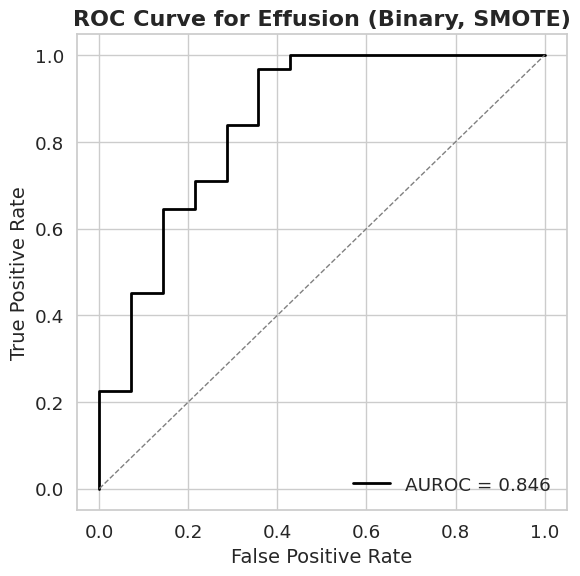

In [15]:
# 설명 변수
X = df.iloc[:, 4:17].fillna(0)
y = df['Effusion']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 SMOTE 적용
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sm, y_train_sm)

y_pred_proba = log_reg.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print("Effusion AUROC (with SMOTE):", auc_score)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,6))
sns.set(style="whitegrid", font_scale=1.2)
plt.plot(fpr, tpr, color="black", lw=2, label=f"AUROC = {auc_score:.3f}")
plt.plot([0,1],[0,1],"--",color="gray",lw=1)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve for Effusion (Binary, SMOTE)", fontsize=16, weight="bold")
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


In [17]:

# Target = Effusion grade (0,1,2)
y_grade = df['Effusion grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_grade, test_size=0.2, random_state=42, stratify=y_grade)

# 🔹 SMOTE for multi-class
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

# 모델 학습 (One-vs-Rest Logistic Regression)
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
clf.fit(X_train_sm, y_train_sm)

# 예측
y_score = clf.predict_proba(X_test)

# Multi-class AUROC
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])
auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print("Effusion Grade AUROC (macro):", auc_macro)
print("Effusion Grade AUROC (micro):", auc_micro)


Before SMOTE: {1: 72, 0: 53, 2: 51}
After SMOTE: {2: 72, 0: 72, 1: 72}
Effusion Grade AUROC (macro): 0.6550654683495184
Effusion Grade AUROC (micro): 0.671358024691358


Effusion / Effusion Grade & Full pipeline with CI + p-values (Colab-safe)


--------------------------------------------------------------------------------
BINARY: Effusion (0/1) — Base vs SMOTE
Base  AUROC = 0.816  (95% CI 0.652-0.945)
SMOTE AUROC = 0.839  (95% CI 0.687-0.962)
DeLong p-value (SMOTE vs Base): 1.0000


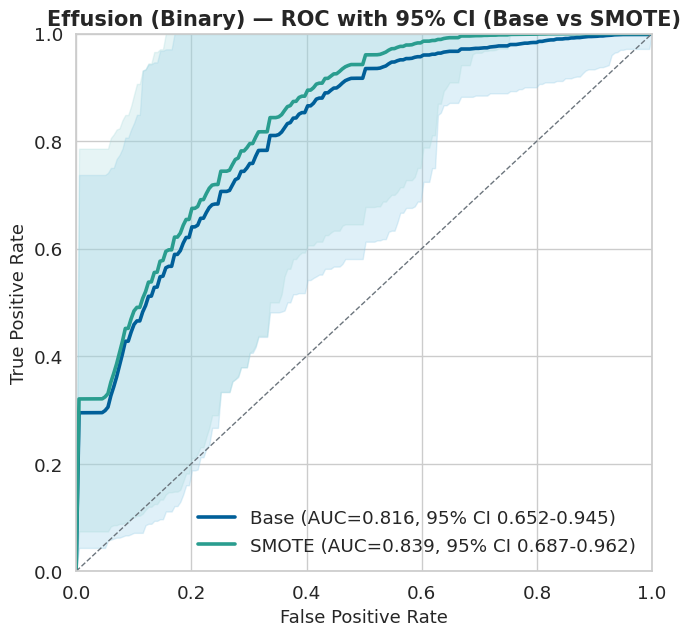


--------------------------------------------------------------------------------
MULTICLASS: Effusion grade (0/1/2) — Base vs SMOTE
Per-class AUROC (Base):  {0: np.float64(0.753), 1: np.float64(0.626), 2: np.float64(0.519)}
Per-class AUROC (SMOTE): {0: np.float64(0.737), 1: np.float64(0.718), 2: np.float64(0.517)}
Macro AUROC - Base: 0.633, SMOTE: 0.657
Micro AUROC - Base: 0.650, SMOTE: 0.673

--------------------------------------------------------------------------------
Multiclass comparison — bootstrap p-values
Macro diff mean: 0.025, 95% CI (np.float64(-0.03), np.float64(0.079)), p=0.3530
Micro diff mean: 0.024, 95% CI (np.float64(-0.024), np.float64(0.073)), p=0.3430
Class 0 diff mean: -0.016, 95% CI (np.float64(-0.053), np.float64(0.011)), p=0.2800
Class 1 diff mean: 0.093, 95% CI (np.float64(-0.008), np.float64(0.202)), p=0.0770
Class 2 diff mean: 0.000, 95% CI (np.float64(-0.093), np.float64(0.092)), p=1.0040


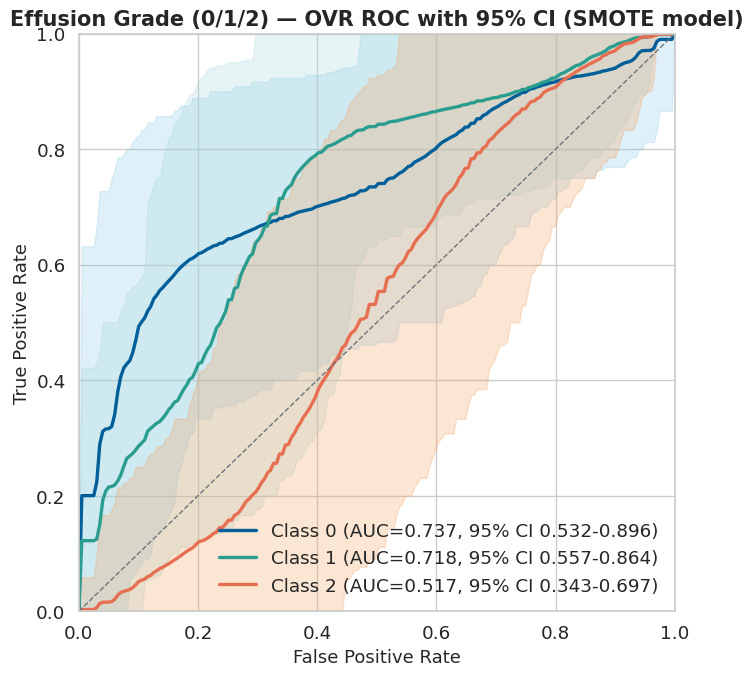


--------------------------------------------------------------------------------
Summary — Binary (DeLong), Multiclass (bootstrap)
Model  AUROC  CI_low  CI_high
 Base  0.816   0.652    0.945
SMOTE  0.839   0.687    0.962
DeLong p-value (SMOTE vs Base): 1.0000
     Metric  Base  SMOTE  Diff_mean(SMOTE-Base)  Diff_95%CI_low  Diff_95%CI_high  p_value
Macro AUROC 0.633  0.657                  0.025          -0.030            0.079    0.353
Micro AUROC 0.650  0.673                  0.024          -0.024            0.073    0.343
 Class  Base_AUROC  SMOTE_AUROC  Diff_mean  Diff_95%CI_low  Diff_95%CI_high  p_value
     0       0.753        0.737     -0.016          -0.053            0.011    0.280
     1       0.626        0.718      0.093          -0.008            0.202    0.077
     2       0.519        0.517      0.000          -0.093            0.092    1.004


In [18]:
# ----------------------------
# Helper 0) Pretty print line
# ----------------------------
def line(msg=""):
    print("\n" + "-"*80)
    if msg:
        print(msg)


# ---------------------------------------------------
# Helper 1) DeLong's test (binary, pure python)
# ---------------------------------------------------
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i+j-1)+1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def _fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]
    aucs = []
    v01 = np.zeros((k, m))
    v10 = np.zeros((k, n))

    for r in range(k):
        v01[r, :] = _compute_midrank(pos[r, :])
        v10[r, :] = _compute_midrank(neg[r, :])
        aucs.append((v01[r, :].mean() - v10[r, :].mean())/(m*n))

    aucs = np.array(aucs)
    s01 = np.cov(v01)
    s10 = np.cov(v10)
    s = s01/m + s10/n
    return aucs, s

def delong_pvalue(y_true, pred1, pred2):
    """
    DeLong's test p-value for two correlated ROC AUCs.
    y_true: 0/1 array-like
    pred1, pred2: predicted probabilities for positive class
    """
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-pred1)  # sort by first model scores descending
    y_true = y_true[order]
    preds = np.array([pred1, pred2])[:, order]
    label_1_count = int(np.sum(y_true))
    aucs, cov = _fastDeLong(preds, label_1_count)
    diff = aucs[0] - aucs[1]
    var = cov[0,0] + cov[1,1] - 2*cov[0,1]
    z = diff / (np.sqrt(var) + 1e-12)
    p = 2*stats.norm.sf(abs(z))
    return diff, p


# ---------------------------------------------------
# Helper 2) Bootstrap CI for AUC (binary)
# ---------------------------------------------------
def bootstrap_auc_ci(y_true, y_score, n_boot=2000, seed=42, alpha=0.95):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt = y_true[idx]
        ys = y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, ys))
    aucs = np.array(aucs)
    lo = np.percentile(aucs, (1-alpha)/2*100)
    hi = np.percentile(aucs, (1+(alpha))/2*100)
    return lo, hi, aucs


# ---------------------------------------------------
# Helper 3) Bootstrap ROC band (binary)
# ---------------------------------------------------
def bootstrap_roc_band(y_true, y_score, n_boot=2000, seed=42, grid_points=200):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    fpr_grid = np.linspace(0, 1, grid_points)
    tprs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt = y_true[idx]
        ys = y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        fpr_b, tpr_b, _ = roc_curve(yt, ys)
        tpr_i = np.interp(fpr_grid, fpr_b, tpr_b)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)
    tprs = np.array(tprs)
    return fpr_grid, np.nanmean(tprs, axis=0), np.nanpercentile(tprs, 2.5, axis=0), np.nanpercentile(tprs, 97.5, axis=0)


# ---------------------------------------------------
# Helper 4) Bootstrap CI & p-value for multiclass metrics
# (macro/micro & per-class OVR AUC, paired comparison Base vs SMOTE)
# ---------------------------------------------------
def multiclass_bootstrap_compare(y_true, proba_base, proba_smote, classes=(0,1,2), n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    n = len(y_true)
    # binarize once per bootstrap
    diffs_macro, diffs_micro = [], []
    diffs_per_class = {c: [] for c in classes}

    macro_base_list, macro_smote_list = [], []
    micro_base_list, micro_smote_list = [], []
    per_class_base, per_class_smote = {c: [] for c in classes}, {c: [] for c in classes}

    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_bs = y_true[idx]
        yb_bin = label_binarize(y_bs, classes=classes)
        pb_base = proba_base[idx]
        pb_smote = proba_smote[idx]

        # macro/micro AUC
        try:
            mac_b = roc_auc_score(yb_bin, pb_base, average="macro")
            mic_b = roc_auc_score(yb_bin, pb_base, average="micro")
            mac_s = roc_auc_score(yb_bin, pb_smote, average="macro")
            mic_s = roc_auc_score(yb_bin, pb_smote, average="micro")
        except ValueError:
            # occurs when a class missing entirely in bootstrap sample
            continue

        diffs_macro.append(mac_s - mac_b)
        diffs_micro.append(mic_s - mic_b)
        macro_base_list.append(mac_b); macro_smote_list.append(mac_s)
        micro_base_list.append(mic_b); micro_smote_list.append(mic_s)

        # per-class
        for i, c in enumerate(classes):
            yt_i = yb_bin[:, i]
            if len(np.unique(yt_i)) < 2:
                continue
            auc_b = roc_auc_score(yt_i, pb_base[:, i])
            auc_s = roc_auc_score(yt_i, pb_smote[:, i])
            diffs_per_class[c].append(auc_s - auc_b)
            per_class_base[c].append(auc_b)
            per_class_smote[c].append(auc_s)

    # CI & p-values (two-sided, H0: diff=0)
    def ci(arr):
        return np.percentile(arr, 2.5), np.percentile(arr, 97.5)
    def pval(arr):
        arr = np.array(arr)
        # symmetric two-sided around zero:
        return 2 * min((arr <= 0).mean(), (arr >= 0).mean())

    out = {}

    # macro
    out['macro'] = {
        'diff_mean': float(np.mean(diffs_macro)) if len(diffs_macro) else np.nan,
        'diff_CI': ci(diffs_macro) if len(diffs_macro) else (np.nan, np.nan),
        'p_value': pval(diffs_macro) if len(diffs_macro) else np.nan,
        'base_CI': ci(macro_base_list) if len(macro_base_list) else (np.nan, np.nan),
        'smote_CI': ci(macro_smote_list) if len(macro_smote_list) else (np.nan, np.nan),
    }
    # micro
    out['micro'] = {
        'diff_mean': float(np.mean(diffs_micro)) if len(diffs_micro) else np.nan,
        'diff_CI': ci(diffs_micro) if len(diffs_micro) else (np.nan, np.nan),
        'p_value': pval(diffs_micro) if len(diffs_micro) else np.nan,
        'base_CI': ci(micro_base_list) if len(micro_base_list) else (np.nan, np.nan),
        'smote_CI': ci(micro_smote_list) if len(micro_smote_list) else (np.nan, np.nan),
    }

    # per-class
    out['per_class'] = {}
    for c in classes:
        arr = diffs_per_class[c]
        out['per_class'][c] = {
            'diff_mean': float(np.mean(arr)) if len(arr) else np.nan,
            'diff_CI': ci(arr) if len(arr) else (np.nan, np.nan),
            'p_value': pval(arr) if len(arr) else np.nan,
            'base_CI': ci(per_class_base[c]) if len(per_class_base[c]) else (np.nan, np.nan),
            'smote_CI': ci(per_class_smote[c]) if len(per_class_smote[c]) else (np.nan, np.nan),
        }
    return out


# =========================
# 1) Binary: Effusion (0/1)
# =========================
line("BINARY: Effusion (0/1) — Base vs SMOTE")

# Outcome/Features
y_bin_out = df['Effusion'].astype(int)
X_feat    = df.iloc[:, 4:17].fillna(0)  # Age~Bruxism

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_feat, y_bin_out, test_size=0.2, random_state=42, stratify=y_bin_out
)

# ----- Base model -----
sc_base = StandardScaler().fit(X_tr)
X_tr_b = sc_base.transform(X_tr)
X_te_b = sc_base.transform(X_te)

m_base = LogisticRegression(max_iter=1000, random_state=42)
m_base.fit(X_tr_b, y_tr)
proba_base = m_base.predict_proba(X_te_b)[:, 1]

auc_base = roc_auc_score(y_te, proba_base)
ciL_b, ciU_b, boot_b = bootstrap_auc_ci(y_te, proba_base, n_boot=2000, seed=42)

# ----- SMOTE model -----
sm = SMOTE(random_state=42)
X_tr_s, y_tr_s = sm.fit_resample(X_tr, y_tr)

sc_sm = StandardScaler().fit(X_tr_s)
X_tr_s = sc_sm.transform(X_tr_s)
X_te_s = sc_sm.transform(X_te)

m_sm = LogisticRegression(max_iter=1000, random_state=42)
m_sm.fit(X_tr_s, y_tr_s)
proba_sm = m_sm.predict_proba(X_te_s)[:, 1]

auc_sm = roc_auc_score(y_te, proba_sm)
ciL_s, ciU_s, boot_s = bootstrap_auc_ci(y_te, proba_sm, n_boot=2000, seed=42)

# ----- DeLong test -----
diff_auc, p_delong = delong_pvalue(y_te, proba_sm, proba_base)

print(f"Base  AUROC = {auc_base:.3f}  (95% CI {ciL_b:.3f}-{ciU_b:.3f})")
print(f"SMOTE AUROC = {auc_sm:.3f}  (95% CI {ciL_s:.3f}-{ciU_s:.3f})")
print(f"DeLong p-value (SMOTE vs Base): {p_delong:.4f}")

# ----- Plot: Base vs SMOTE, both with CI bands -----
fpr_b, mean_b, low_b, up_b = bootstrap_roc_band(y_te, proba_base, n_boot=2000, seed=42)
fpr_s, mean_s, low_s, up_s = bootstrap_roc_band(y_te, proba_sm,   n_boot=2000, seed=42)

plt.figure(figsize=(7.0, 6.6))
# Base: navy line, sky band
plt.fill_between(fpr_b, low_b, up_b, color="#8ecae6", alpha=0.28)
plt.plot(fpr_b, mean_b, color="#005f99", lw=2.6,
         label=f"Base (AUC={auc_base:.3f}, 95% CI {ciL_b:.3f}-{ciU_b:.3f})")
# SMOTE: teal line, mint band
plt.fill_between(fpr_s, low_s, up_s, color="#a8dadc", alpha=0.28)
plt.plot(fpr_s, mean_s, color="#2a9d8f", lw=2.6,
         label=f"SMOTE (AUC={auc_sm:.3f}, 95% CI {ciL_s:.3f}-{ciU_s:.3f})")

plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion (Binary) — ROC with 95% CI (Base vs SMOTE)", fontsize=15, fontweight="bold")
plt.xlim(0,1); plt.ylim(0,1)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


# ========================================
# 2) Multiclass: Effusion grade (0/1/2)
# ========================================
line("MULTICLASS: Effusion grade (0/1/2) — Base vs SMOTE")

classes = [0,1,2]
y_mc_out = df['Effusion grade'].astype(int)

# Split (동일 seed/비율, 멀티클래스용)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_feat, y_mc_out, test_size=0.2, random_state=42, stratify=y_mc_out
)

# ----- Base OVR Logistic -----
sc_b = StandardScaler().fit(X_tr)
X_tr_b = sc_b.transform(X_tr)
X_te_b = sc_b.transform(X_te)

ovr_b = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr_b.fit(X_tr_b, y_tr)
proba_b = ovr_b.predict_proba(X_te_b)   # (n,3)

y_te_bin = label_binarize(y_te, classes=classes)
# per-class
auc_b_per = {c: roc_auc_score(y_te_bin[:,i], proba_b[:,i]) for i,c in enumerate(classes)}
# macro/micro
auc_b_macro = roc_auc_score(y_te_bin, proba_b, average="macro")
auc_b_micro = roc_auc_score(y_te_bin, proba_b, average="micro")

# ----- SMOTE OVR Logistic -----
sm = SMOTE(random_state=42)
X_tr_s, y_tr_s = sm.fit_resample(X_tr, y_tr)

sc_s = StandardScaler().fit(X_tr_s)
X_tr_s = sc_s.transform(X_tr_s)
X_te_s = sc_s.transform(X_te)

ovr_s = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr_s.fit(X_tr_s, y_tr_s)
proba_s = ovr_s.predict_proba(X_te_s)

# per-class
auc_s_per = {c: roc_auc_score(y_te_bin[:,i], proba_s[:,i]) for i,c in enumerate(classes)}
# macro/micro
auc_s_macro = roc_auc_score(y_te_bin, proba_s, average="macro")
auc_s_micro = roc_auc_score(y_te_bin, proba_s, average="micro")

print("Per-class AUROC (Base): ", {k: round(v,3) for k,v in auc_b_per.items()})
print("Per-class AUROC (SMOTE):", {k: round(v,3) for k,v in auc_s_per.items()})
print(f"Macro AUROC - Base: {auc_b_macro:.3f}, SMOTE: {auc_s_macro:.3f}")
print(f"Micro AUROC - Base: {auc_b_micro:.3f}, SMOTE: {auc_s_micro:.3f}")

# ----- Bootstrap paired comparison: macro/micro & per-class -----
mc_cmp = multiclass_bootstrap_compare(y_te, proba_b, proba_s, classes=classes, n_boot=2000, seed=42)

line("Multiclass comparison — bootstrap p-values")
print(f"Macro diff mean: {mc_cmp['macro']['diff_mean']:.3f}, 95% CI {tuple(round(x,3) for x in mc_cmp['macro']['diff_CI'])}, p={mc_cmp['macro']['p_value']:.4f}")
print(f"Micro diff mean: {mc_cmp['micro']['diff_mean']:.3f}, 95% CI {tuple(round(x,3) for x in mc_cmp['micro']['diff_CI'])}, p={mc_cmp['micro']['p_value']:.4f}")

for c in classes:
    d = mc_cmp['per_class'][c]
    print(f"Class {c} diff mean: {d['diff_mean']:.3f}, 95% CI {tuple(round(x,3) for x in d['diff_CI'])}, p={d['p_value']:.4f}")

# ----- Plot: Multiclass OVR ROC (SMOTE model ONLY, with 95% CI per class & legend AUC+CI) -----
# (요청: 그래프 범례에는 해당 클래스 AUC와 95% CI만 표기; macro/micro는 표로 보고)
# CI band 계산 (per-class, SMOTE)
def per_class_roc_band(y_true_bin, proba, seed=42, n_boot=2000, grid_points=200):
    rng = np.random.RandomState(seed)
    n = y_true_bin.shape[0]
    fpr_grid = np.linspace(0,1,grid_points)
    out = {}
    for i,c in enumerate(classes):
        tprs = []
        for _ in range(n_boot):
            idx = rng.randint(0, n, n)
            yt = y_true_bin[idx, i]
            ys = proba[idx, i]
            if len(np.unique(yt)) < 2:
                continue
            fpr_b, tpr_b, _ = roc_curve(yt, ys)
            tpr_i = np.interp(fpr_grid, fpr_b, tpr_b)
            tpr_i[0] = 0.0
            tprs.append(tpr_i)
        tprs = np.array(tprs)
        out[c] = {
            'fpr_grid': fpr_grid,
            'tpr_mean': np.nanmean(tprs, axis=0),
            'tpr_low' : np.nanpercentile(tprs, 2.5, axis=0),
            'tpr_up'  : np.nanpercentile(tprs, 97.5, axis=0),
        }
    return out

bands_s = per_class_roc_band(y_te_bin, proba_s, seed=42, n_boot=2000, grid_points=200)

# 클래스별 색상
line_colors = {0: "#005f99", 1: "#2a9d8f", 2: "#e76f51"}   # 라인
band_colors = {0: "#8ecae6", 1: "#a8dadc", 2: "#f4a261"}   # 밴드

# per-class AUC 95% CI (SMOTE) — bootstrap on test set (unpaired CI)
def per_class_auc_ci(y_true_bin, proba, seed=42, n_boot=2000):
    rng = np.random.RandomState(seed)
    n = y_true_bin.shape[0]
    ci = {}
    for i,c in enumerate(classes):
        aucs = []
        for _ in range(n_boot):
            idx = rng.randint(0, n, n)
            yt = y_true_bin[idx, i]
            ys = proba[idx, i]
            if len(np.unique(yt)) < 2:
                continue
            aucs.append(roc_auc_score(yt, ys))
        if len(aucs):
            ci[c] = (np.percentile(aucs, 2.5), np.percentile(aucs, 97.5))
        else:
            ci[c] = (np.nan, np.nan)
    return ci

ci_s_perclass = per_class_auc_ci(y_te_bin, proba_s, seed=42, n_boot=2000)

# Plot
plt.figure(figsize=(7.2, 7.0))
for i,c in enumerate(classes):
    grd = bands_s[c]['fpr_grid']
    mean= bands_s[c]['tpr_mean']
    low = bands_s[c]['tpr_low']
    up  = bands_s[c]['tpr_up']

    plt.fill_between(grd, low, up, color=band_colors[c], alpha=0.28)
    lo, hi = ci_s_perclass[c]
    plt.plot(grd, mean, color=line_colors[c], lw=2.4,
             label=f"Class {c} (AUC={auc_s_per[c]:.3f}, 95% CI {lo:.3f}-{hi:.3f})")

plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion Grade (0/1/2) — OVR ROC with 95% CI (SMOTE model)", fontsize=15, fontweight="bold")
plt.xlim(0,1); plt.ylim(0,1)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

# ----- Summary tables (concise) -----
line("Summary — Binary (DeLong), Multiclass (bootstrap)")
binary_summary = pd.DataFrame([{
    "Model": "Base",  "AUROC": round(auc_base,3),  "CI_low": round(ciL_b,3), "CI_high": round(ciU_b,3)
},{
    "Model": "SMOTE", "AUROC": round(auc_sm,3),    "CI_low": round(ciL_s,3), "CI_high": round(ciU_s,3)
}])
print(binary_summary.to_string(index=False))
print(f"DeLong p-value (SMOTE vs Base): {p_delong:.4f}")

multi_summary = pd.DataFrame([
    {"Metric": "Macro AUROC", "Base": round(auc_b_macro,3), "SMOTE": round(auc_s_macro,3),
     "Diff_mean(SMOTE-Base)": round(mc_cmp['macro']['diff_mean'],3),
     "Diff_95%CI_low": round(mc_cmp['macro']['diff_CI'][0],3),
     "Diff_95%CI_high": round(mc_cmp['macro']['diff_CI'][1],3),
     "p_value": round(mc_cmp['macro']['p_value'],4)},
    {"Metric": "Micro AUROC", "Base": round(auc_b_micro,3), "SMOTE": round(auc_s_micro,3),
     "Diff_mean(SMOTE-Base)": round(mc_cmp['micro']['diff_mean'],3),
     "Diff_95%CI_low": round(mc_cmp['micro']['diff_CI'][0],3),
     "Diff_95%CI_high": round(mc_cmp['micro']['diff_CI'][1],3),
     "p_value": round(mc_cmp['micro']['p_value'],4)},
])
print(multi_summary.to_string(index=False))

perclass_rows = []
for c in classes:
    d = mc_cmp['per_class'][c]
    perclass_rows.append({
        "Class": c,
        "Base_AUROC": round(auc_b_per[c],3),
        "SMOTE_AUROC": round(auc_s_per[c],3),
        "Diff_mean": round(d['diff_mean'],3),
        "Diff_95%CI_low": round(d['diff_CI'][0],3),
        "Diff_95%CI_high": round(d['diff_CI'][1],3),
        "p_value": round(d['p_value'],4)
    })
print(pd.DataFrame(perclass_rows).to_string(index=False))
